# 03 - Neural Network Model

Prediction of Daily Mean TEC using Solar and Geomagnetic Indices

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
ROOT = Path.cwd().parent

DATA = ROOT / 'data' / 'processed' / 'master_dataset.csv'
RESULTS = ROOT / 'results'
MODELS = ROOT / 'models'

RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,daily_mean_tec,ssn,kp_mean,ap_daily,f107_obs,f107_adj,dst_daily_mean
0,2022-01-01,19.980,48.0,2.416625,12.0,93.9,90.8,-11.125000
1,2022-01-02,19.680,27.0,2.041500,9.0,89.0,86.0,-9.708333
2,2022-01-03,18.256,10.0,2.416625,12.0,84.0,81.3,-10.833333
3,2022-01-04,17.548,10.0,1.083250,5.0,85.5,82.7,-10.083333
4,2022-01-05,15.896,23.0,0.625000,2.0,83.7,81.0,-3.583333


## Feature Selection

In [5]:
features = [
    "ssn",
    "kp_mean",
    "ap_daily",
    "f107_obs",
    "dst_daily_mean",
    "sin_doy",
    "cos_doy",
]

target = 'daily_mean_tec'

data = df[features + [target]].dropna()

X = data[features]
y = data[target]

## Train / Validation / Test Split

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print('Training:', len(X_train))
print('Validation:', len(X_val))
print('Testing:', len(X_test))

Training: 766
Validation: 164
Testing: 165


## Standardization

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Neural Network Architecture

In [11]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1664.6628 - mae: 39.6472 - val_loss: 1580.3423 - val_mae: 38.6397
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1621.7229 - mae: 39.1055 - val_loss: 1520.8711 - val_mae: 37.8701
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1540.1913 - mae: 38.0559 - val_loss: 1408.2229 - val_mae: 36.3600
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1392.1841 - mae: 36.0552 - val_loss: 1215.2941 - val_mae: 33.5707
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1151.2889 - mae: 32.5347 - val_loss: 922.9230 - val_mae: 28.6714
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 819.3328 - mae: 26.7766 - val_loss: 588.3199 - val_mae: 21.8394
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 498.5610 - mae: 19.4901 - val_loss: 370.8971 - val_mae: 16.1843
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 324.9092 - mae: 14.4734 - val_loss: 317.2231 - val_mae: 13.9488
Epoch 

## Learning Curve

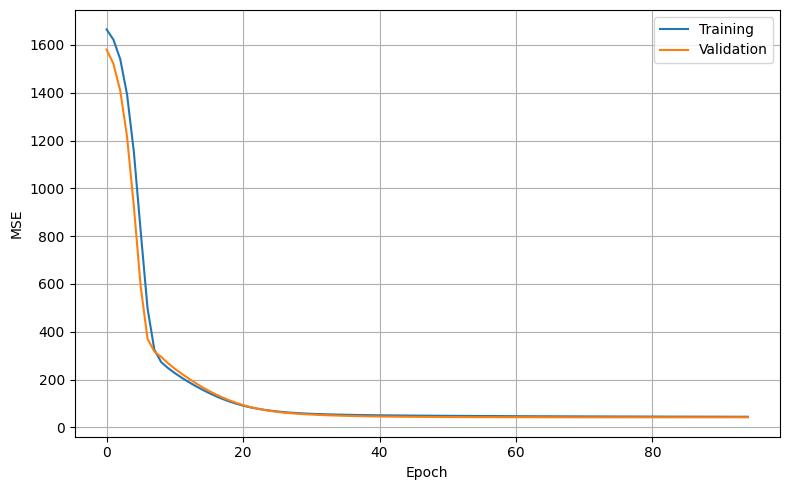

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Evaluation

In [17]:
predictions = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE  : {mae:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R²   : {r2:.3f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
MAE  : 6.010
RMSE : 7.223
R²   : 0.458


## Observed vs Predicted

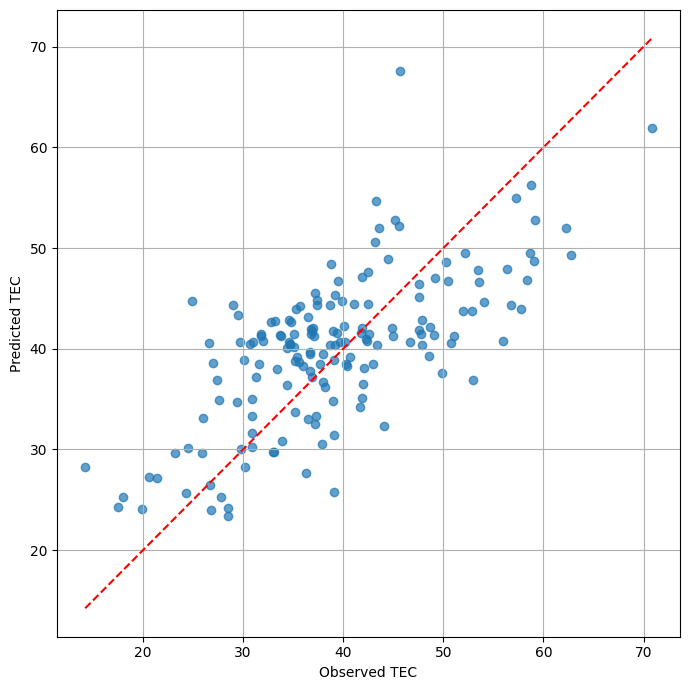

In [19]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, predictions, alpha=0.7)
mn = min(y_test.min(), predictions.min())
mx = max(y_test.max(), predictions.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Observed TEC')
plt.ylabel('Predicted TEC')
plt.grid(True)
plt.tight_layout()
plt.show()

## Residual Analysis

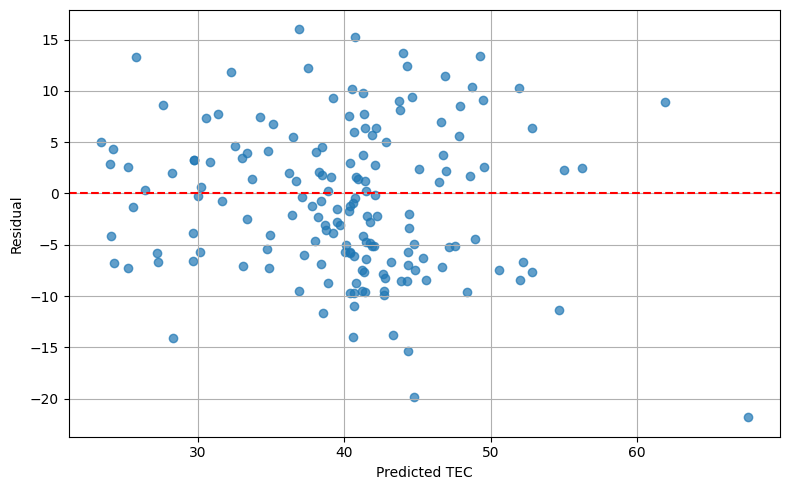

In [21]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))
plt.scatter(predictions, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted TEC')
plt.ylabel('Residual')
plt.grid(True)
plt.tight_layout()
plt.show()

## Save Results

In [23]:
results = pd.DataFrame({
    'Observed': y_test.values,
    'Predicted': predictions,
    'Residual': residuals
})

results.to_csv(RESULTS / 'nn_predictions.csv', index=False)

model.save(MODELS / 'tec_neural_network.keras')

print('Saved predictions and trained model.')

Saved predictions and trained model.
